In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

In [12]:
def plot(traffic_name, with_MD:bool):
    # Plotting
    plt.figure(figsize=(8, 3))

    # Load CSV data
    csv_file = f'/users/ziyzhang/topology-research/Nexullance_journal_data_gen/pertubation/data/DDF_36_5_{traffic_name}_perturbation.csv'  # Replace with the actual file path
    data = pd.read_csv(csv_file)
    # Dynamically get the last three column names
    last_three_columns = data.columns[-3:]
    # Enforce the last three columns as float
    data[last_three_columns] = data[last_three_columns].astype(float)
    # Group by 'perturbation_rate' and calculate mean and std for the last three columns
    grouped_data = data.groupby('perturbation_rate').agg(
        mean_col1=(last_three_columns[0], 'mean'),
        std_col1=(last_three_columns[0], 'std'),
        mean_col2=(last_three_columns[1], 'mean'),
        std_col2=(last_three_columns[1], 'std'),
        mean_col3=(last_three_columns[2], 'mean'),
        std_col3=(last_three_columns[2], 'std')
    ).reset_index()

    # First series (col1)
    plt.errorbar(grouped_data['perturbation_rate'], grouped_data['mean_col1'],
                yerr=grouped_data['std_col1'], label=last_three_columns[0], fmt='-o')
    # Second series (col2)
    plt.errorbar(grouped_data['perturbation_rate'], grouped_data['mean_col2'],
                yerr=grouped_data['std_col2'], label=last_three_columns[1], fmt='-o')
    # Third series (col3)
    plt.errorbar(grouped_data['perturbation_rate'], grouped_data['mean_col3'],
                yerr=grouped_data['std_col3'], label=last_three_columns[2], fmt='-o')

    if with_MD:
        # MD_Nexullance
        csv_file = f'/users/ziyzhang/topology-research/Nexullance_journal_data_gen/pertubation/data/DDF_36_5_{traffic_name}_MD_MP_perturbation.csv'  # Replace with the actual file path
        data = pd.read_csv(csv_file)
        # Dynamically get the last three column names
        last_three_columns = data.columns[-3:]
        # Enforce the last three columns as float
        data[last_three_columns] = data[last_three_columns].astype(float)
        # Group by 'perturbation_rate' and calculate mean and std for the last three columns
        grouped_data = data.groupby('perturbation_rate').agg(
            mean_col1=(last_three_columns[0], 'mean'),
            std_col1=(last_three_columns[0], 'std'),
            mean_col2=(last_three_columns[1], 'mean'),
            std_col2=(last_three_columns[1], 'std'),
            mean_col3=(last_three_columns[2], 'mean'),
            std_col3=(last_three_columns[2], 'std')
        ).reset_index()


        # First series (col1)
        plt.errorbar(grouped_data['perturbation_rate'], grouped_data['mean_col1'],
                    yerr=grouped_data['std_col1'], label=last_three_columns[0], fmt='-o')
        # Second series (col2)
        plt.errorbar(grouped_data['perturbation_rate'], grouped_data['mean_col2'],
                    yerr=grouped_data['std_col2'], label=last_three_columns[1], fmt='-o')
        # Third series (col3)
        plt.errorbar(grouped_data['perturbation_rate'], grouped_data['mean_col3'],
                    yerr=grouped_data['std_col3'], label=last_three_columns[2], fmt='-o')



    # Customize the plot
    plt.xlabel('Perturbation Rate')
    plt.ylabel('per-EP network \n data throughput [Gbps]')
    plt.ylim(0,11)
    plt.title('Comparison of different routings with Perturbation')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.grid(True)

    # Show the plot
    plt.tight_layout()
    plt.show()


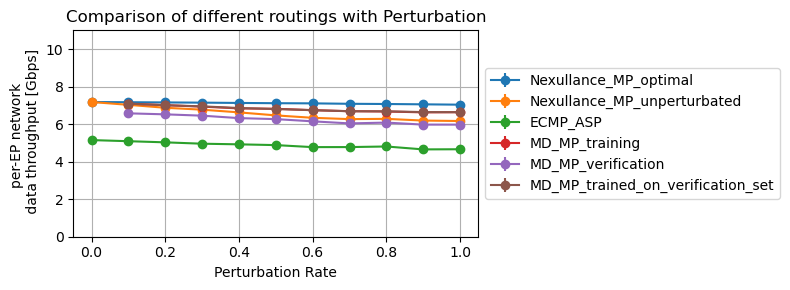

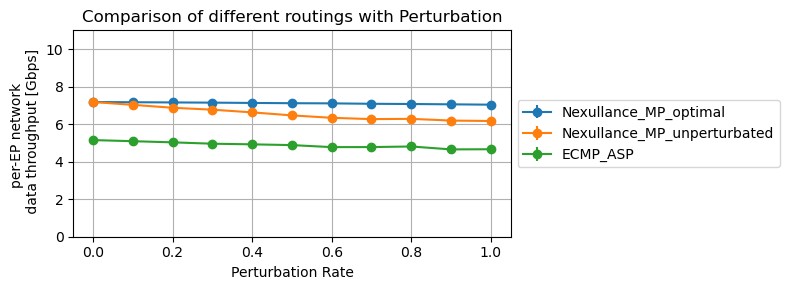

In [13]:
plot("uniform", True)
plot("uniform", False)
# plot("shift-1")
# plot("shift-half")
# plot("nearst-neighbour")